In [1]:
import requests

url = "https://zenodo.org/api/records/20429763"

data = requests.get(url).json()

for file in data["files"]:
    print(file["key"])
    print(file["size"])
    print(file["links"]["self"])
    print()

vishguard_dataset.zip
6454015665
https://zenodo.org/api/records/20429763/files/vishguard_dataset.zip/content



In [2]:
!wget -c "https://zenodo.org/api/records/20429763/files/vishguard_dataset.zip/content" \
    -O /kaggle/working/vishguard_dataset.zip

--2026-08-20 06:58:12--  https://zenodo.org/api/records/20429763/files/vishguard_dataset.zip/content
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6454015665 (6.0G) [application/octet-stream]
Saving to: ‘/kaggle/working/vishguard_dataset.zip’

/kaggle/working/vis 100%[===================>]   6.01G  4.09MB/s    in 22m 44s 

2026-08-20 07:20:57 (4.51 MB/s) - ‘/kaggle/working/vishguard_dataset.zip’ saved [6454015665/6454015665]



In [3]:
import os

path = "/kaggle/working/vishguard_dataset.zip"

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    size_gb = os.path.getsize(path) / (1024**3)
    print(f"Size: {size_gb:.2f} GB")

Exists: True
Size: 6.01 GB


In [4]:
import zipfile

zip_path = "/kaggle/working/vishguard_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.infolist()

print("Total files:", len(files))
print("\nFirst 100 files:\n")

for f in files[:100]:
    print(f"{f.filename}  |  {f.file_size / (1024**2):.2f} MB")

Total files: 6150

First 100 files:

vishguard_dataset/  |  0.00 MB
vishguard_dataset/annotations_with_audio.json  |  2.57 MB
vishguard_dataset/audio/  |  0.00 MB
vishguard_dataset/audio/lot10_ar_fraud_1000.wav  |  5.07 MB
vishguard_dataset/audio/lot10_ar_fraud_906.wav  |  5.77 MB
vishguard_dataset/audio/lot10_ar_fraud_909.wav  |  2.34 MB
vishguard_dataset/audio/lot10_ar_fraud_916.wav  |  2.78 MB
vishguard_dataset/audio/lot10_ar_fraud_923.wav  |  5.79 MB
vishguard_dataset/audio/lot10_ar_fraud_929.wav  |  5.22 MB
vishguard_dataset/audio/lot10_ar_fraud_936.wav  |  2.59 MB
vishguard_dataset/audio/lot10_ar_fraud_943.wav  |  4.61 MB
vishguard_dataset/audio/lot10_ar_fraud_949.wav  |  5.15 MB
vishguard_dataset/audio/lot10_ar_fraud_956.wav  |  2.36 MB
vishguard_dataset/audio/lot10_ar_fraud_963.wav  |  4.73 MB
vishguard_dataset/audio/lot10_ar_fraud_969.wav  |  4.55 MB
vishguard_dataset/audio/lot10_ar_fraud_976.wav  |  2.70 MB
vishguard_dataset/audio/lot10_ar_fraud_983.wav  |  4.74 MB
vishguard_

In [5]:
from collections import Counter

with zipfile.ZipFile(zip_path, "r") as z:
    extensions = Counter()

    for f in z.infolist():
        if not f.is_dir():
            name = f.filename.lower()

            if "." in name:
                ext = name.rsplit(".", 1)[-1]
            else:
                ext = "[no extension]"

            extensions[ext] += 1

print("Files by extension:")
for ext, count in extensions.most_common():
    print(f"{ext:15} {count}")

Files by extension:
txt             3061
wav             3059
py              12
md              4
csv             3
json            2
ini             1
[no extension]  1
xlsx            1


In [6]:
from collections import defaultdict

with zipfile.ZipFile(zip_path, "r") as z:
    sizes = defaultdict(int)

    for f in z.infolist():
        if not f.is_dir():
            name = f.filename.lower()
            ext = name.rsplit(".", 1)[-1] if "." in name else "[no extension]"
            sizes[ext] += f.file_size

print("Uncompressed size by extension:\n")

for ext, size in sorted(sizes.items(), key=lambda x: x[1], reverse=True):
    print(f"{ext:15} {size / (1024**3):.2f} GB")

Uncompressed size by extension:

wav             7.54 GB
json            0.00 GB
txt             0.00 GB
py              0.00 GB
md              0.00 GB
xlsx            0.00 GB
[no extension]  0.00 GB
csv             0.00 GB
ini             0.00 GB


In [7]:
import zipfile
import json

zip_path = "/kaggle/working/vishguard_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:

    # Read annotation JSON directly from ZIP
    with z.open("vishguard_dataset/annotations_with_audio.json") as f:
        annotations = json.load(f)

print("Type:", type(annotations))

if isinstance(annotations, list):
    print("Number of records:", len(annotations))
    print("\nFirst record:")
    print(json.dumps(annotations[0], indent=2, ensure_ascii=False))

elif isinstance(annotations, dict):
    print("Top-level keys:")
    print(annotations.keys())

    print("\nSample:")
    print(json.dumps(annotations, indent=2, ensure_ascii=False)[:5000])

Type: <class 'list'>
Number of records: 3059

First record:
{
  "id": "lot1_en_fraud_001",
  "type": "fraudulent",
  "language": "en",
  "script": "Attention, your bank account has been locked due to suspected money laundering activity. An official government agent is on the line. Failure to cooperate immediately will result in a warrant for your arrest being issued within the hour. You must urgently transfer your funds to our secure verification wallet. Time is running out to avoid legal prosecution.",
  "duration": 21.01,
  "emotion": [
    "fear",
    "authority"
  ],
  "tone": [
    "threat",
    "authoritative"
  ],
  "persuasion_patterns": [
    "threat",
    "urgency",
    "authority"
  ],
  "behavior": [
    "irregular_speech",
    "interruptions"
  ],
  "metadata": {
    "words_count": 115,
    "audio_path": "audio/lot1/en_fraud_001.wav"
  },
  "audio_path": "audio\\lot1_en_fraud_001.wav"
}


In [8]:
with zipfile.ZipFile(zip_path, "r") as z:

    txt_files = [
        f.filename for f in z.infolist()
        if f.filename.lower().endswith(".txt")
    ]

    print("First TXT:", txt_files[0])

    with z.open(txt_files[0]) as f:
        text = f.read().decode("utf-8", errors="replace")

    print("\nTranscript content:\n")
    print(text[:3000])

First TXT: vishguard_dataset/scripts/requirements.txt

Transcript content:

numpy>=1.24
scipy>=1.10
scikit-learn>=1.3
librosa>=0.10.1
soundfile>=0.12
pandas>=2.0
torch>=2.0
torchaudio>=2.0
transformers>=4.35
tqdm>=4.66



In [9]:
import zipfile
import json
from collections import Counter
from pathlib import PurePosixPath

zip_path = "/kaggle/working/vishguard_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:

    # Load annotations
    with z.open("vishguard_dataset/annotations_with_audio.json") as f:
        annotations = json.load(f)

    print("Total records:", len(annotations))

    # -----------------------------
    # 1. Label distribution
    # -----------------------------
    type_counts = Counter(a.get("type") for a in annotations)
    print("\nLabel distribution:")
    for k, v in type_counts.items():
        print(f"{k}: {v}")

    # -----------------------------
    # 2. Language distribution
    # -----------------------------
    lang_counts = Counter(a.get("language") for a in annotations)
    print("\nLanguage distribution:")
    for k, v in lang_counts.most_common():
        print(f"{k}: {v}")

    # -----------------------------
    # 3. Duration statistics
    # -----------------------------
    durations = [
        a.get("duration")
        for a in annotations
        if isinstance(a.get("duration"), (int, float))
    ]

    print("\nDuration statistics:")
    print(f"Min:    {min(durations):.2f} sec")
    print(f"Max:    {max(durations):.2f} sec")
    print(f"Mean:   {sum(durations)/len(durations):.2f} sec")

    # -----------------------------
    # 4. Check audio paths
    # -----------------------------
    zip_names = set(z.namelist())

    found = 0
    missing = 0

    for a in annotations:
        audio_path = a.get("audio_path", "").replace("\\", "/")

        # JSON path may be "audio/lot1_en_fraud_001.wav"
        full_path = "vishguard_dataset/" + audio_path

        if full_path in zip_names:
            found += 1
        else:
            missing += 1

    print("\nAudio path check:")
    print("Found :", found)
    print("Missing:", missing)

    # -----------------------------
    # 5. Show one legitimate call
    # -----------------------------
    legit = next(
        (a for a in annotations
         if str(a.get("type", "")).lower() in ["legitimate", "legit"]),
        None
    )

    if legit:
        print("\nExample legitimate record:")
        print(json.dumps(legit, indent=2, ensure_ascii=False))

    # -----------------------------
    # 6. Find actual transcript/script files
    # -----------------------------
    transcript_candidates = [
        f for f in zip_names
        if f.lower().endswith(".txt")
        and "requirements.txt" not in f.lower()
        and "/scripts/" not in f.lower()
    ]

    print("\nPossible transcript TXT files:", len(transcript_candidates))

    for f in transcript_candidates[:10]:
        print(f)

Total records: 3059

Label distribution:
fraudulent: 1530
legitimate: 1529

Language distribution:
en: 1065
ar: 998
fr: 996

Duration statistics:
Min:    10.00 sec
Max:    38.05 sec
Mean:   21.74 sec

Audio path check:
Found : 3059
Missing: 0

Example legitimate record:
{
  "id": "lot1_fr_legit_002",
  "type": "legitimate",
  "language": "fr",
  "script": "Bonjour, c'est le support technique d'Orange. Nous avons reçu votre signalement concernant la coupure internet. Nos équipes travaillent actuellement sur un incident réseau majeur dans votre quartier. La restauration complète est prévue pour 18 heures. Nous vous présentons nos excuses pour ce désagrément.",
  "duration": 15.43,
  "emotion": [
    "neutral",
    "reassuring"
  ],
  "tone": [
    "professional"
  ],
  "persuasion_patterns": [],
  "behavior": [],
  "metadata": {
    "words_count": 55,
    "audio_path": "audio/lot1/fr_legit_002.wav"
  },
  "audio_path": "audio\\lot1_fr_legit_002.wav"
}

Possible transcript TXT files: 3059

In [10]:
#cell 9

import json
import zipfile
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import seaborn as sns

print("Imports ready.")

Imports ready.


In [12]:
#cell 10

zip_path = "/kaggle/working/vishguard_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("vishguard_dataset/annotations_with_audio.json") as f:
        annotations = json.load(f)

df_voice = pd.DataFrame(annotations)

print("Dataset shape:", df_voice.shape)

display(
    df_voice[
        [
            "id",
            "type",
            "language",
            "script",
            "duration",
            "emotion",
            "tone",
            "persuasion_patterns",
            "behavior"
        ]
    ].head()
)

Dataset shape: (3059, 11)


,id,type,language,script,duration,emotion,tone,persuasion_patterns,behavior
0,lot1_en_fraud_001,fraudulent,en,"Attention, your bank account has been locked d...",21.01,"[fear, authority]","[threat, authoritative]","[threat, urgency, authority]","[irregular_speech, interruptions]"
1,lot1_fr_legit_002,legitimate,fr,"Bonjour, c'est le support technique d'Orange. ...",15.43,"[neutral, reassuring]",[professional],[],[]
2,lot1_ar_fraud_003,fraudulent,ar,تهانينا! لقد ربحت رحلة مجانية إلى دبي لمدة سبع...,21.71,"[urgency, excitement]","[manipulative, warm]","[reward, scarcity, urgency]",[]
3,lot1_en_legit_004,legitimate,en,This is a notification from City Hall. Your pr...,18.11,[neutral],[professional],[],[long_silence]
4,lot1_fr_fraud_005,fraudulent,fr,Ceci est un ordre de la Direction Générale. Vo...,18.73,"[authority, fear]","[authoritative, threat]","[authority, threat]",[irregular_speech]


In [13]:
#cell 11

df_voice = df_voice[
    ["id", "type", "language", "script", "duration",
     "emotion", "tone", "persuasion_patterns", "behavior", "audio_path"]
].copy()

df_voice["script"] = (
    df_voice["script"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df_voice["label"] = (
    df_voice["type"]
    .map({
        "legitimate": 0,
        "fraudulent": 1
    })
)

df_voice = df_voice.dropna(subset=["label"])

df_voice["label"] = df_voice["label"].astype(int)

print("Shape:", df_voice.shape)

print("\nLabel distribution:")
print(df_voice["label"].value_counts())

print("\nMissing scripts:", (df_voice["script"] == "").sum())

Shape: (3059, 11)

Label distribution:
label
1    1530
0    1529
Name: count, dtype: int64

Missing scripts: 0


In [14]:
#cell 12

print("Example fraudulent transcript:\n")
print(
    df_voice[df_voice["label"] == 1]["script"].iloc[0]
)

print("\n" + "=" * 80)

print("\nExample legitimate transcript:\n")
print(
    df_voice[df_voice["label"] == 0]["script"].iloc[0]
)

Example fraudulent transcript:

Attention, your bank account has been locked due to suspected money laundering activity. An official government agent is on the line. Failure to cooperate immediately will result in a warrant for your arrest being issued within the hour. You must urgently transfer your funds to our secure verification wallet. Time is running out to avoid legal prosecution.


Example legitimate transcript:

Bonjour, c'est le support technique d'Orange. Nous avons reçu votre signalement concernant la coupure internet. Nos équipes travaillent actuellement sur un incident réseau majeur dans votre quartier. La restauration complète est prévue pour 18 heures. Nous vous présentons nos excuses pour ce désagrément.


In [15]:
#cell 13

X_text = df_voice["script"]
y = df_voice["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train_text))
print("Test samples:", len(X_test_text))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Training samples: 2447
Test samples: 612

Training label distribution:
label
1    1224
0    1223
Name: count, dtype: int64

Test label distribution:
label
0    306
1    306
Name: count, dtype: int64


In [16]:
#cell 14

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [17]:
#cell 15

X_train_embeddings = embedding_model.encode(
    X_train_text.tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Training embeddings shape:", X_train_embeddings.shape)

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Training embeddings shape: (2447, 384)


In [18]:
#cell 16

X_test_embeddings = embedding_model.encode(
    X_test_text.tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("Test embeddings shape:", X_test_embeddings.shape)

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Test embeddings shape: (612, 384)


In [19]:
#cell 17

voice_classifier = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

voice_classifier.fit(
    X_train_embeddings,
    y_train
)

print("Voice classifier trained.")

Voice classifier trained.


In [20]:
#cell 18

test_probabilities = voice_classifier.predict_proba(
    X_test_embeddings
)[:, 1]

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

In [21]:
#cell 19

accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

Accuracy : 0.9967
Precision: 0.9967
Recall   : 0.9967
F1       : 0.9967
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       306
  Fraudulent       1.00      1.00      1.00       306

    accuracy                           1.00       612
   macro avg       1.00      1.00      1.00       612
weighted avg       1.00      1.00      1.00       612



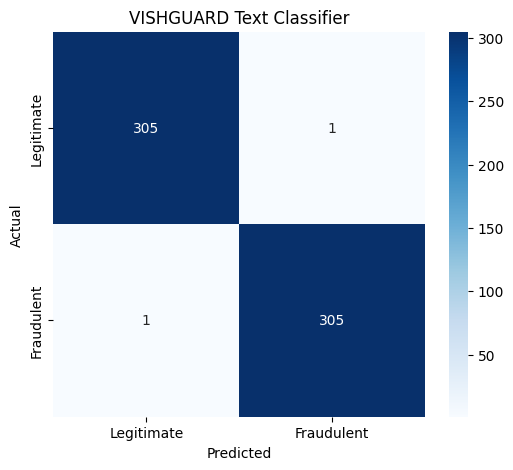

In [22]:
#cell 20

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VISHGUARD Text Classifier")
plt.show()

In [23]:
#cell 21

test_indices = X_test_text.index

language_results = []

for language in df_voice.loc[test_indices, "language"].unique():

    mask = df_voice.loc[test_indices, "language"] == language

    language_indices = test_indices[mask]

    positions = [
        list(test_indices).index(idx)
        for idx in language_indices
    ]

    y_true_lang = y_test.iloc[positions]
    y_pred_lang = test_predictions[positions]

    language_results.append({
        "language": language,
        "samples": len(y_true_lang),
        "precision": precision_score(
            y_true_lang,
            y_pred_lang,
            zero_division=0
        ),
        "recall": recall_score(
            y_true_lang,
            y_pred_lang,
            zero_division=0
        ),
        "f1": f1_score(
            y_true_lang,
            y_pred_lang,
            zero_division=0
        )
    })

language_results = pd.DataFrame(language_results)

display(language_results)

,language,samples,precision,recall,f1
0,ar,216,1.00,1.000000,1.000000
1,fr,197,1.00,0.990385,0.995169
2,en,199,0.99,1.000000,0.994975


In [24]:
#cell 22

import re


RISK_PATTERNS = {
    "otp": [
        r"\botp\b",
        r"one[- ]time password",
        r"verification code",
        r"رمز التحقق",
        r"كود التحقق",
        r"code de vérification"
    ],

    "pin": [
        r"\bpin\b",
        r"password",
        r"الرقم السري",
        r"الرقم السري لبطاقتك",
        r"mot de passe"
    ],

    "urgency": [
        r"urgent",
        r"immediately",
        r"right now",
        r"act now",
        r"time is running out",
        r"فوراً",
        r"فورا",
        r"الآن",
        r"عاجل",
        r"immédiatement"
    ],

    "threat": [
        r"account.*blocked",
        r"account.*suspended",
        r"arrest",
        r"legal action",
        r"police",
        r"prosecution",
        r"السجن",
        r"جريمة",
        r"الشرطة",
        r"القائمة السوداء",
        r"gouvernement",
        r"arrestation"
    ],

    "authority": [
        r"bank official",
        r"government",
        r"security department",
        r"police officer",
        r"official",
        r"agent",
        r"ضابط",
        r"شرطة",
        r"الشرطة الفيدرالية",
        r"هيئة الجمارك",
        r"حكومة",
        r"agent bancaire",
        r"gouvernement"
    ],

    "money_transfer": [
        r"transfer.*funds",
        r"send.*money",
        r"secure wallet",
        r"verification wallet",
        r"transfer",
        r"تحويل",
        r"إرسال دفعة",
        r"دفعة تعويضية",
        r"بيتكوين",
        r"محفظة",
        r"transférer",
        r"portefeuille"
    ],

    "secrecy": [
        r"do not tell",
        r"keep.*secret",
        r"don't tell anyone",
        r"لا تخبر أحد",
        r"سري",
        r"ne dites à personne"
    ]
}


def detect_risk_signals(text):
    text = str(text).lower().strip()

    detected = []

    for signal, patterns in RISK_PATTERNS.items():
        for pattern in patterns:
            if re.search(pattern, text, flags=re.IGNORECASE):
                detected.append(signal)
                break

    return detected


df_voice["risk_signals"] = df_voice["script"].apply(
    detect_risk_signals
)

display(
    df_voice[
        ["language", "label", "script", "risk_signals"]
    ].head(10)
)

,language,label,script,risk_signals
0,en,1,"Attention, your bank account has been locked d...","[urgency, threat, authority, money_transfer]"
1,fr,0,"Bonjour, c'est le support technique d'Orange. ...",[]
2,ar,1,تهانينا! لقد ربحت رحلة مجانية إلى دبي لمدة سبع...,"[otp, urgency]"
3,en,0,This is a notification from City Hall. Your pr...,[]
4,fr,1,Ceci est un ordre de la Direction Générale. Vo...,"[pin, urgency]"
5,ar,0,نحن نتصل لتأكيد موعدك مع طبيب الأسنان غدًا الس...,[]
6,en,1,"Hello, I am calling from tech support. We have...",[urgency]
7,fr,0,Ceci est un message de l'école de votre enfant...,[]
8,ar,1,نتصل بك من وزارة التجارة. لديك شكوى معلقة ستؤد...,[urgency]
9,en,0,"Good afternoon, we are calling to follow up on...",[threat]


In [25]:
#cell 23

SIGNAL_WEIGHTS = {
    "otp": 25,
    "pin": 20,
    "urgency": 15,
    "threat": 20,
    "authority": 15,
    "money_transfer": 15,
    "secrecy": 10
}


def calculate_rule_risk(signals):

    score = sum(
        SIGNAL_WEIGHTS.get(signal, 0)
        for signal in signals
    )

    return min(score, 100)


df_voice["rule_risk"] = df_voice["risk_signals"].apply(
    calculate_rule_risk
)

print(
    df_voice[
        ["label", "risk_signals", "rule_risk"]
    ].head(20)
)

    label                                  risk_signals  rule_risk
0       1  [urgency, threat, authority, money_transfer]         65
1       0                                            []          0
2       1                                [otp, urgency]         40
3       0                                            []          0
4       1                                [pin, urgency]         35
5       0                                            []          0
6       1                                     [urgency]         15
7       0                                            []          0
8       1                                     [urgency]         15
9       0                                      [threat]         20
10      1                                [pin, urgency]         35
11      0                                            []          0
12      1                                            []          0
13      0                                            []       

In [26]:
#cell 24

ml_risk = test_probabilities * 100

rule_risks = []

for idx in X_test_text.index:

    signals = df_voice.loc[idx, "risk_signals"]

    rule_risks.append(
        df_voice.loc[idx, "rule_risk"]
    )

rule_risks = np.array(rule_risks)

final_voice_risk = (
    0.70 * ml_risk +
    0.30 * rule_risks
)

final_voice_risk = np.clip(
    final_voice_risk,
    0,
    100
)

print("Voice risk calculated.")
print("Min:", final_voice_risk.min())
print("Max:", final_voice_risk.max())
print("Mean:", final_voice_risk.mean())

Voice risk calculated.
Min: 0.04474778530665644
Max: 97.50707542503866
Mean: 39.49087709705367


In [27]:
#cell 25

example_idx = X_test_text.index[0]

example_text = df_voice.loc[
    example_idx,
    "script"
]

example_signals = df_voice.loc[
    example_idx,
    "risk_signals"
]

example_rule_risk = df_voice.loc[
    example_idx,
    "rule_risk"
]

print("Transcript:")
print(example_text)

print("\nDetected signals:")
print(example_signals)

print("\nRule risk:")
print(example_rule_risk)

Transcript:
مرحباً، نتصل بك من مدرسة القيادة. نود أن نذكرك بأن فصول القيادة النظرية تبدأ غداً في تمام الساعة 9 صباحاً. يرجى إحضار رخصة المتعلم الخاصة بك. نتطلع إلى رؤيتك هناك. شكراً لك.

Detected signals:
[]

Rule risk:
0


In [28]:
#cell 26

import joblib
import os

VOICE_MODEL_DIR = "/kaggle/working/fraudshield_voice_model"

os.makedirs(
    VOICE_MODEL_DIR,
    exist_ok=True
)

joblib.dump(
    voice_classifier,
    f"{VOICE_MODEL_DIR}/voice_classifier.joblib"
)

joblib.dump(
    {
        "embedding_model": EMBEDDING_MODEL_NAME,
        "signal_weights": SIGNAL_WEIGHTS,
        "risk_patterns": RISK_PATTERNS
    },
    f"{VOICE_MODEL_DIR}/voice_config.joblib"
)

print("Voice model artifacts saved.")
print(VOICE_MODEL_DIR)

Voice model artifacts saved.
/kaggle/working/fraudshield_voice_model


In [29]:
#cell 27

df_voice[
    [
        "id",
        "type",
        "language",
        "duration",
        "risk_signals",
        "rule_risk"
    ]
].to_csv(
    "/kaggle/working/vishguard_processed_metadata.csv",
    index=False
)

print("Processed metadata saved.")

Processed metadata saved.


In [30]:
#cell 28

VOICE_MODEL_DIR = "/kaggle/working/fraudshield_voice_model"

embedding_save_path = f"{VOICE_MODEL_DIR}/embedding_model"

embedding_model.save(
    embedding_save_path
)

print("Embedding model saved:")
print(embedding_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding model saved:
/kaggle/working/fraudshield_voice_model/embedding_model


In [31]:
#cell 29

import os

print("Saved voice model files:")

for root, dirs, files in os.walk(VOICE_MODEL_DIR):
    level = root.replace(VOICE_MODEL_DIR, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")



Saved voice model files:
fraudshield_voice_model/
  voice_classifier.joblib
  voice_config.joblib
  embedding_model/
    modules.json
    model.safetensors
    tokenizer.json
    README.md
    tokenizer_config.json
    config.json
    config_sentence_transformers.json
    sentence_bert_config.json
    1_Pooling/
      config.json


In [32]:
#cell 30

manual_texts = [
    "Your bank account will be blocked immediately. Give me your OTP now.",
    "This is a normal reminder that your driving class starts tomorrow at 9 AM.",
    "I am calling from the bank security department. Transfer the money to this secure wallet.",
    "Hello, your internet service appointment is confirmed for tomorrow afternoon."
]

manual_embeddings = embedding_model.encode(
    manual_texts,
    normalize_embeddings=True
)

manual_probs = voice_classifier.predict_proba(
    manual_embeddings
)[:, 1]

manual_results = pd.DataFrame({
    "text": manual_texts,
    "fraud_probability": manual_probs,
    "risk_score": manual_probs * 100
})

display(manual_results)

,text,fraud_probability,risk_score
0,Your bank account will be blocked immediately....,0.742905,74.290516
1,This is a normal reminder that your driving cl...,0.022096,2.209621
2,I am calling from the bank security department...,0.829974,82.997386
3,"Hello, your internet service appointment is co...",0.004143,0.414264


In [33]:
#cell 31

import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [34]:
!pip install -q faster-whisper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 57.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 51.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 74.6 MB/s eta 0:00:00:00:0100:01


In [35]:
#cell 32

from faster_whisper import WhisperModel

WHISPER_MODEL_SIZE = "small"

whisper_model = WhisperModel(
    WHISPER_MODEL_SIZE,
    device="cuda" if torch.cuda.is_available() else "cpu",
    compute_type="float16" if torch.cuda.is_available() else "int8"
)

print("Whisper model loaded.")

Whisper model loaded.


In [36]:
#cell 33

import zipfile
import os

# Select a balanced multilingual Whisper evaluation sample:
# 2 fraudulent + 2 legitimate samples for each language.

SAMPLES_PER_CLASS_PER_LANGUAGE = 2
TARGET_LANGUAGES = ["en", "fr", "ar"]

audio_samples = []

with zipfile.ZipFile(zip_path, "r") as z:

    zip_names = set(z.namelist())

    for language in TARGET_LANGUAGES:

        for label_value, label_name in [
            (1, "fraudulent"),
            (0, "legitimate")
        ]:

            subset = df_voice[
                (df_voice["language"] == language) &
                (df_voice["label"] == label_value)
            ].copy()

            subset = subset.sample(
                n=SAMPLES_PER_CLASS_PER_LANGUAGE,
                random_state=42
            )

            for _, row in subset.iterrows():

                audio_path = str(
                    row["audio_path"]
                ).replace("\\", "/")

                full_zip_path = (
                    "vishguard_dataset/" + audio_path
                )

                if full_zip_path not in zip_names:
                    print(
                        "WARNING: Audio not found:",
                        full_zip_path
                    )
                    continue

                audio_samples.append({
                    "id": row["id"],
                    "language": row["language"],
                    "label": row["label"],
                    "type": row["type"],
                    "zip_path": full_zip_path,
                    "filename": os.path.basename(audio_path)
                })

audio_samples_df = pd.DataFrame(audio_samples)

print("Selected Whisper evaluation samples:")
print(
    audio_samples_df[
        [
            "id",
            "language",
            "type",
            "filename"
        ]
    ]
)

print("\nSample distribution:")
print(
    audio_samples_df
    .groupby(["language", "type"])
    .size()
    .unstack(fill_value=0)
)

print(
    "\nTotal selected samples:",
    len(audio_samples_df)
)

Selected Whisper evaluation samples:
                     id language        type                 filename
0     lot8_en_fraud_798       en  fraudulent    lot8_en_fraud_798.wav
1   lot22_en_fraud_2192       en  fraudulent  lot22_en_fraud_2192.wav
2     lot6_en_legit_570       en  legitimate    lot6_en_legit_570.wav
3     lot8_en_legit_713       en  legitimate    lot8_en_legit_713.wav
4   lot17_fr_fraud_1626       fr  fraudulent  lot17_fr_fraud_1626.wav
5     lot5_fr_fraud_424       fr  fraudulent    lot5_fr_fraud_424.wav
6   lot28_fr_legit_2773       fr  legitimate  lot28_fr_legit_2773.wav
7     lot5_fr_legit_442       fr  legitimate    lot5_fr_legit_442.wav
8   lot28_ar_fraud_2776       ar  fraudulent  lot28_ar_fraud_2776.wav
9     lot4_ar_fraud_368       ar  fraudulent    lot4_ar_fraud_368.wav
10  lot28_ar_legit_2775       ar  legitimate  lot28_ar_legit_2775.wav
11    lot4_ar_legit_399       ar  legitimate    lot4_ar_legit_399.wav

Sample distribution:
type      fraudulent  legitimat

In [37]:
#cell 34

sample_dir = "/kaggle/working/vishguard_audio_samples"
os.makedirs(sample_dir, exist_ok=True)

extracted_audio_paths = []

with zipfile.ZipFile(zip_path, "r") as z:

    for sample in audio_samples:

        output_path = z.extract(
            sample["zip_path"],
            sample_dir
        )

        extracted_audio_paths.append(output_path)

        print(
            "Extracted:",
            output_path
        )

print(
    "\nTotal extracted audio files:",
    len(extracted_audio_paths)
)

Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot8_en_fraud_798.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot22_en_fraud_2192.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot6_en_legit_570.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot8_en_legit_713.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot17_fr_fraud_1626.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot5_fr_fraud_424.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot28_fr_legit_2773.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot5_fr_legit_442.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot28_ar_fraud_2776.wav
Extracted: /kaggle/working/vishguard_audio_samples/vishguard_dataset/audio/lot4_ar_fraud_368.wav
Extracted: /kaggle/wor

In [38]:
#cell 35

results = []

for audio_path in extracted_audio_paths:

    print(
        "\nTranscribing:",
        os.path.basename(audio_path)
    )

    segments, info = whisper_model.transcribe(
        audio_path,
        beam_size=5
    )

    transcript = " ".join(
        segment.text.strip()
        for segment in segments
    ).strip()

    filename = os.path.basename(audio_path)

    metadata_match = audio_samples_df[
        audio_samples_df["filename"] == filename
    ]

    if len(metadata_match) > 0:

        metadata = metadata_match.iloc[0]

        results.append({
            "file": filename,
            "id": metadata["id"],
            "language_expected": metadata["language"],
            "label": metadata["label"],
            "type": metadata["type"],
            "language_detected": info.language,
            "transcript": transcript
        })

    print(
        "Expected language:",
        metadata["language"]
        if len(metadata_match) > 0
        else "unknown"
    )

    print(
        "Detected language:",
        info.language
    )

    print(
        "Transcript:",
        transcript
    )

whisper_results = pd.DataFrame(results)

print(
    "\nWhisper results shape:",
    whisper_results.shape
)

display(whisper_results)


Transcribing: lot8_en_fraud_798.wav
Expected language: en
Detected language: en
Transcript: Your social security number has been flagged by the FBI for massive fraud and identity theft. This is a severe federal offense. I am the only high-ranking agent who can offer you an immediate path to compliance. You must immediately pay the $3,000 bond using the prepaid gift card I instructed you to buy. This is a one-time reward to avoid jail. If you hang up, you face immediate arrest. You must comply with my authority right now.

Transcribing: lot22_en_fraud_2192.wav
Expected language: en
Detected language: en
Transcript: I am a high-ranking officer from the local police department. An outstanding warrant has been issued against you for identity theft. I am the only one with the authority to cancel the warrant. You must immediately pay an $850 bail bond using Bitcoin to clear the warrant. If you hang up, the SWAT team will be dispatched. You must obey my authority right now.

Transcribing: lo

,file,id,language_expected,label,type,language_detected,transcript
0,lot8_en_fraud_798.wav,lot8_en_fraud_798,en,1,fraudulent,en,Your social security number has been flagged b...
1,lot22_en_fraud_2192.wav,lot22_en_fraud_2192,en,1,fraudulent,en,I am a high-ranking officer from the local pol...
2,lot6_en_legit_570.wav,lot6_en_legit_570,en,0,legitimate,en,This call is regarding your recent warranty cl...
3,lot8_en_legit_713.wav,lot8_en_legit_713,en,0,legitimate,en,This message is from the city library. The boo...
4,lot17_fr_fraud_1626.wav,lot17_fr_fraud_1626,fr,1,fraudulent,fr,Je suis un agent de la caisse d'allocation fam...
5,lot5_fr_fraud_424.wav,lot5_fr_fraud_424,fr,1,fraudulent,fr,"Félicitations, vous avez gagné un abonnement p..."
6,lot28_fr_legit_2773.wav,lot28_fr_legit_2773,fr,0,legitimate,fr,"Bonjour, ceci est un rappel de la Banque Crédi..."
7,lot5_fr_legit_442.wav,lot5_fr_legit_442,fr,0,legitimate,fr,Ceci est un message de la clinique dentaire. N...
8,lot28_ar_fraud_2776.wav,lot28_ar_fraud_2776,ar,1,fraudulent,ar,أنا عقيد من جهاز الأمن الوطني تم رصدك وانت تقو...
9,lot4_ar_fraud_368.wav,lot4_ar_fraud_368,ar,1,fraudulent,ar,أنا ضابت كبير من الشلطة الفيدرالية تم استخدامه...


In [39]:
#cell 36

for _, row in whisper_results.iterrows():

    record_id = row["id"]

    matches = df_voice[
        df_voice["id"] == record_id
    ]

    print("\n" + "=" * 80)
    print("ID:", record_id)
    print("FILE:", row["file"])
    print("Expected Language:", row["language_expected"])
    print("Detected Language:", row["language_detected"])
    print("Type:", row["type"])

    if len(matches) > 0:
        print("\nGROUND TRUTH:")
        print(matches.iloc[0]["script"])
    else:
        print("\nGROUND TRUTH:")
        print("Not found")

    print("\nWHISPER TRANSCRIPT:")
    print(row["transcript"])


ID: lot8_en_fraud_798
FILE: lot8_en_fraud_798.wav
Expected Language: en
Detected Language: en
Type: fraudulent

GROUND TRUTH:
Your social security number has been flagged by the FBI for massive fraud and identity theft. This is a severe federal offense. I am the only high-ranking agent who can offer you an immediate path to compliance. You must immediately pay the $3,000 bond using the prepaid gift card I instructed you to buy. This is a one-time reward to avoid jail. If you hang up, you face immediate arrest. You must comply with my authority right now.

WHISPER TRANSCRIPT:
Your social security number has been flagged by the FBI for massive fraud and identity theft. This is a severe federal offense. I am the only high-ranking agent who can offer you an immediate path to compliance. You must immediately pay the $3,000 bond using the prepaid gift card I instructed you to buy. This is a one-time reward to avoid jail. If you hang up, you face immediate arrest. You must comply with my aut

In [40]:
#cell 37

!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.3 MB/s eta 0:00:00:00:01


In [41]:
#cell 38

from jiwer import wer
import re
import unicodedata


def normalize_text_for_wer(text):
    text = str(text)

    # Normalize Unicode representation
    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Lowercase
    text = text.lower()

    # Remove punctuation while preserving letters/numbers
    text = re.sub(
        r"[^\w\s]",
        " ",
        text,
        flags=re.UNICODE
    )

    # Collapse repeated whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


wer_results = []

for _, row in whisper_results.iterrows():

    record_id = row["id"]

    matches = df_voice[
        df_voice["id"] == record_id
    ]

    if len(matches) == 0:
        continue

    ground_truth = matches.iloc[0]["script"]
    whisper_text = row["transcript"]

    raw_error = wer(
        ground_truth,
        whisper_text
    )

    normalized_ground_truth = normalize_text_for_wer(
        ground_truth
    )

    normalized_whisper_text = normalize_text_for_wer(
        whisper_text
    )

    normalized_error = wer(
        normalized_ground_truth,
        normalized_whisper_text
    )

    wer_results.append({
        "id": record_id,
        "file": row["file"],
        "expected_language": row["language_expected"],
        "detected_language": row["language_detected"],
        "type": row["type"],
        "raw_WER": raw_error,
        "normalized_WER": normalized_error
    })


wer_df = pd.DataFrame(wer_results)

display(wer_df)

print("\nOverall WER")
print("=" * 80)

print(
    f"Mean raw WER        : "
    f"{wer_df['raw_WER'].mean():.4f}"
)

print(
    f"Mean normalized WER : "
    f"{wer_df['normalized_WER'].mean():.4f}"
)

print("\nWER by language")
print("=" * 80)

language_wer = (
    wer_df
    .groupby("expected_language")
    .agg(
        samples=("id", "count"),
        raw_WER=("raw_WER", "mean"),
        normalized_WER=("normalized_WER", "mean")
    )
    .reset_index()
)

display(language_wer)

print("\nLanguage detection accuracy")
print("=" * 80)

language_detection_accuracy = (
    wer_df["expected_language"]
    == wer_df["detected_language"]
).mean()

print(
    f"Whisper language detection accuracy: "
    f"{language_detection_accuracy:.4f}"
)

,id,file,expected_language,detected_language,type,raw_WER,normalized_WER
0,lot8_en_fraud_798,lot8_en_fraud_798.wav,en,en,fraudulent,0.000000,0.000000
1,lot22_en_fraud_2192,lot22_en_fraud_2192.wav,en,en,fraudulent,0.031250,0.000000
2,lot6_en_legit_570,lot6_en_legit_570.wav,en,en,legitimate,0.086957,0.086957
3,lot8_en_legit_713,lot8_en_legit_713.wav,en,en,legitimate,0.026316,0.000000
4,lot17_fr_fraud_1626,lot17_fr_fraud_1626.wav,fr,fr,fraudulent,0.115942,0.085714
5,lot5_fr_fraud_424,lot5_fr_fraud_424.wav,fr,fr,fraudulent,0.089286,0.035714
6,lot28_fr_legit_2773,lot28_fr_legit_2773.wav,fr,fr,legitimate,0.142857,0.055556
7,lot5_fr_legit_442,lot5_fr_legit_442.wav,fr,fr,legitimate,0.000000,0.000000
8,lot28_ar_fraud_2776,lot28_ar_fraud_2776.wav,ar,ar,fraudulent,0.375000,0.204082
9,lot4_ar_fraud_368,lot4_ar_fraud_368.wav,ar,ar,fraudulent,0.395833,0.354167



Overall WER
Mean raw WER        : 0.1502
Mean normalized WER : 0.0888

WER by language


,expected_language,samples,raw_WER,normalized_WER
0,ar,4,0.327463,0.200361
1,en,4,0.036131,0.021739
2,fr,4,0.087021,0.044246



Language detection accuracy
Whisper language detection accuracy: 1.0000


In [42]:
#cell 39

whisper_embeddings = embedding_model.encode(
    whisper_results["transcript"].tolist(),
    normalize_embeddings=True
)

whisper_fraud_probability = voice_classifier.predict_proba(
    whisper_embeddings
)[:, 1]

whisper_results["fraud_probability"] = (
    whisper_fraud_probability
)

whisper_results["voice_risk"] = (
    whisper_fraud_probability * 100
)

display(
    whisper_results[
        [
            "file",
            "language_detected",
            "fraud_probability",
            "voice_risk",
            "transcript"
        ]
    ]
)

,file,language_detected,fraud_probability,voice_risk,transcript
0,lot8_en_fraud_798.wav,en,0.997455,99.745496,Your social security number has been flagged b...
1,lot22_en_fraud_2192.wav,en,0.990356,99.035612,I am a high-ranking officer from the local pol...
2,lot6_en_legit_570.wav,en,0.010077,1.007741,This call is regarding your recent warranty cl...
3,lot8_en_legit_713.wav,en,0.007507,0.750723,This message is from the city library. The boo...
4,lot17_fr_fraud_1626.wav,fr,0.987325,98.732515,Je suis un agent de la caisse d'allocation fam...
5,lot5_fr_fraud_424.wav,fr,0.934044,93.404388,"Félicitations, vous avez gagné un abonnement p..."
6,lot28_fr_legit_2773.wav,fr,0.029236,2.923605,"Bonjour, ceci est un rappel de la Banque Crédi..."
7,lot5_fr_legit_442.wav,fr,0.004811,0.481102,Ceci est un message de la clinique dentaire. N...
8,lot28_ar_fraud_2776.wav,ar,0.996006,99.600644,أنا عقيد من جهاز الأمن الوطني تم رصدك وانت تقو...
9,lot4_ar_fraud_368.wav,ar,0.996399,99.639887,أنا ضابت كبير من الشلطة الفيدرالية تم استخدامه...


In [43]:
#cell 40

whisper_results["risk_signals"] = (
    whisper_results["transcript"]
    .apply(detect_risk_signals)
)

whisper_results["rule_risk"] = (
    whisper_results["risk_signals"]
    .apply(calculate_rule_risk)
)

whisper_results["final_voice_risk"] = (
    0.70 * whisper_results["voice_risk"] +
    0.30 * whisper_results["rule_risk"]
)

whisper_results["final_voice_risk"] = (
    whisper_results["final_voice_risk"]
    .clip(0, 100)
)

display(
    whisper_results[
        [
            "id",
            "language_expected",
            "language_detected",
            "type",
            "voice_risk",
            "rule_risk",
            "final_voice_risk",
            "risk_signals"
        ]
    ]
)

,id,language_expected,language_detected,type,voice_risk,rule_risk,final_voice_risk,risk_signals
0,lot8_en_fraud_798,en,en,fraudulent,99.745496,50,84.821847,"[urgency, threat, authority]"
1,lot22_en_fraud_2192,en,en,fraudulent,99.035612,35,79.824928,"[urgency, threat]"
2,lot6_en_legit_570,en,en,legitimate,1.007741,0,0.705418,[]
3,lot8_en_legit_713,en,en,legitimate,0.750723,0,0.525506,[]
4,lot17_fr_fraud_1626,fr,fr,fraudulent,98.732515,50,84.112760,"[pin, urgency, authority]"
5,lot5_fr_fraud_424,fr,fr,fraudulent,93.404388,0,65.383072,[]
6,lot28_fr_legit_2773,fr,fr,legitimate,2.923605,0,2.046523,[]
7,lot5_fr_legit_442,fr,fr,legitimate,0.481102,0,0.336771,[]
8,lot28_ar_fraud_2776,ar,ar,fraudulent,99.600644,60,87.720451,"[urgency, threat, money_transfer, secrecy]"
9,lot4_ar_fraud_368,ar,ar,fraudulent,99.639887,50,84.747921,"[urgency, threat, money_transfer]"


In [44]:
#cell 41

print("Multilingual rule validation")
print("=" * 80)

rule_validation = (
    df_voice
    .groupby(["language", "label"])["risk_signals"]
    .apply(
        lambda x: pd.Series([
            sum(len(signals) > 0 for signals in x),
            sum(len(signals) == 0 for signals in x),
            sum(len(signals) for signals in x)
        ], index=[
            "records_with_signals",
            "records_without_signals",
            "total_detected_signals"
        ])
    )
    .unstack()
    .reset_index()
)

rule_validation["label_name"] = (
    rule_validation["label"]
    .map({
        0: "legitimate",
        1: "fraudulent"
    })
)

display(rule_validation)

print("\nFraud samples by language with detected signals:")
print("=" * 80)

for language in sorted(df_voice["language"].unique()):
    subset = df_voice[
        (df_voice["language"] == language) &
        (df_voice["label"] == 1)
    ]

    detected_count = (
        subset["risk_signals"]
        .apply(len)
        .gt(0)
        .sum()
    )

    total_count = len(subset)

    coverage = (
        detected_count / total_count * 100
        if total_count > 0
        else 0
    )

    print(
        f"{language.upper()}: "
        f"{detected_count}/{total_count} "
        f"fraudulent samples have at least one rule signal "
        f"({coverage:.2f}%)"
    )

Multilingual rule validation


,language,label,records_with_signals,records_without_signals,total_detected_signals,label_name
0,ar,0,50,449,50,legitimate
1,ar,1,459,40,1012,fraudulent
2,en,0,71,465,76,legitimate
3,en,1,496,33,1122,fraudulent
4,fr,0,35,459,37,legitimate
5,fr,1,440,62,821,fraudulent



Fraud samples by language with detected signals:
AR: 459/499 fraudulent samples have at least one rule signal (91.98%)
EN: 496/529 fraudulent samples have at least one rule signal (93.76%)
FR: 440/502 fraudulent samples have at least one rule signal (87.65%)


In [45]:
#cell 42

print("VISHGUARD Audio Pipeline Summary")
print("=" * 80)

print(
    "Total Whisper samples:",
    len(whisper_results)
)

print(
    "\nExpected language distribution:"
)

print(
    whisper_results["language_expected"]
    .value_counts()
)

print(
    "\nDetected language distribution:"
)

print(
    whisper_results["language_detected"]
    .value_counts()
)

print(
    "\nAverage voice risk:",
    f"{whisper_results['voice_risk'].mean():.2f}"
)

print(
    "Average rule risk:",
    f"{whisper_results['rule_risk'].mean():.2f}"
)

print(
    "Average final voice risk:",
    f"{whisper_results['final_voice_risk'].mean():.2f}"
)

print("\nHigh-risk samples:")
print(
    whisper_results[
        whisper_results["final_voice_risk"] >= 60
    ][
        [
            "id",
            "language_expected",
            "language_detected",
            "type",
            "final_voice_risk",
            "risk_signals"
        ]
    ]
)

VISHGUARD Audio Pipeline Summary
Total Whisper samples: 12

Expected language distribution:
language_expected
en    4
fr    4
ar    4
Name: count, dtype: int64

Detected language distribution:
language_detected
en    4
fr    4
ar    4
Name: count, dtype: int64

Average voice risk: 50.38
Average rule risk: 20.42
Average final voice risk: 41.39

High-risk samples:
                    id language_expected language_detected        type  \
0    lot8_en_fraud_798                en                en  fraudulent   
1  lot22_en_fraud_2192                en                en  fraudulent   
4  lot17_fr_fraud_1626                fr                fr  fraudulent   
5    lot5_fr_fraud_424                fr                fr  fraudulent   
8  lot28_ar_fraud_2776                ar                ar  fraudulent   
9    lot4_ar_fraud_368                ar                ar  fraudulent   

   final_voice_risk                                risk_signals  
0         84.821847                [urgency, threa